In [3]:
!pip install gymnasium

In [4]:
!pip install "gymnasium[toy-text]"

In [5]:
import gymnasium as gym
import numpy as np
import random

In [6]:
env=gym.make("CliffWalking-v1")

In [7]:
env

<OrderEnforcing<PassiveEnvChecker<CliffWalkingEnv<CliffWalking-v1>>>>

In [8]:
print(env.observation_space.n)

48


In [9]:
print(env.action_space.n)

4


In [10]:
starting_state,_=env.reset()

In [11]:
print(starting_state)

36


In [12]:
gamma=0.99
alpha=0.5
epsilon=0.1
episodes=500
q=np.zeros((48,4))

In [13]:
def epsilon_greedy(state):
    if random.random()<epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(q[state])
        

In [14]:
for episode in range(episodes):
    env = gym.make("CliffWalking-v1")
    done = False
    
    state, _ = env.reset()
    action = epsilon_greedy(state)
    
    total_reward = 0
    episode_len = 0

    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        next_action = epsilon_greedy(next_state)

        q[state, action] += alpha * (
            reward + gamma * q[next_state, next_action] - q[state, action]
        )

        state = next_state
        action = next_action
        total_reward += reward
        episode_len += 1

    print(f"episode={episode+1}/500: total_reward={total_reward} & ep length={episode_len}")

episode=1/500: total_reward=-58 & ep length=58
episode=2/500: total_reward=-1970 & ep length=584
episode=3/500: total_reward=-335 & ep length=236
episode=4/500: total_reward=-367 & ep length=169
episode=5/500: total_reward=-85 & ep length=85
episode=6/500: total_reward=-87 & ep length=87
episode=7/500: total_reward=-152 & ep length=53
episode=8/500: total_reward=-51 & ep length=51
episode=9/500: total_reward=-74 & ep length=74
episode=10/500: total_reward=-80 & ep length=80
episode=11/500: total_reward=-39 & ep length=39
episode=12/500: total_reward=-224 & ep length=125
episode=13/500: total_reward=-55 & ep length=55
episode=14/500: total_reward=-294 & ep length=96
episode=15/500: total_reward=-51 & ep length=51
episode=16/500: total_reward=-27 & ep length=27
episode=17/500: total_reward=-33 & ep length=33
episode=18/500: total_reward=-33 & ep length=33
episode=19/500: total_reward=-41 & ep length=41
episode=20/500: total_reward=-37 & ep length=37
episode=21/500: total_reward=-52 & ep 

In [15]:
# what did our agent learn?

env = gym.make("CliffWalking-v1", render_mode="human")
state, _ = env.reset()
done = False
total_reward = 0
episode_len = 0

while not done:
    action = np.argmax(q[state])
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    
    total_reward += reward
    episode_len += 1

print(f"total reward = {total_reward} & episode len = {episode_len}")
env.close()

total reward = -17 & episode len = 17


q-learning

In [16]:
import gymnasium as gym
import numpy as np
import random

In [17]:
gamma=0.99
epsilon=0.1
alpha=0.5
episodes=500


In [18]:

q=np.zeros((48,4))

In [19]:
def epsilon_greedy(state):
    if random.random()<epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(q[state])
        

In [20]:
for episode in range(episodes):
    render=(episode%50==0)
    if render:
      env = gym.make("CliffWalking-v1",render_mode="human")
    else:
        env=gym.make("CliffWalking-v1")
    done=False
    state, _ = env.reset()
    total_reward = 0
    episode_len = 0

    while not done:
        action=np.argmax(q[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        # ✅ FIXED INDENTATION
        q[state, action] += alpha * (
            reward + gamma*np.max(q[next_state]) - q[state, action]
        )

        state = next_state
        episode_len+= 1
        total_reward += reward

    # ✅ FIXED PRINT
    print(f"episode={episode+1}/500: total_reward={total_reward} & ep length={episode_len}")
    env.close()

episode=1/500: total_reward=-120 & ep length=120
episode=2/500: total_reward=-1541 & ep length=452
episode=3/500: total_reward=-92 & ep length=92
episode=4/500: total_reward=-83 & ep length=83
episode=5/500: total_reward=-49 & ep length=49
episode=6/500: total_reward=-126 & ep length=126
episode=7/500: total_reward=-42 & ep length=42
episode=8/500: total_reward=-85 & ep length=85
episode=9/500: total_reward=-41 & ep length=41
episode=10/500: total_reward=-74 & ep length=74
episode=11/500: total_reward=-83 & ep length=83
episode=12/500: total_reward=-53 & ep length=53
episode=13/500: total_reward=-60 & ep length=60
episode=14/500: total_reward=-39 & ep length=39
episode=15/500: total_reward=-30 & ep length=30
episode=16/500: total_reward=-28 & ep length=28
episode=17/500: total_reward=-59 & ep length=59
episode=18/500: total_reward=-42 & ep length=42
episode=19/500: total_reward=-62 & ep length=62
episode=20/500: total_reward=-49 & ep length=49
episode=21/500: total_reward=-37 & ep leng

In [21]:
env=gym.make("CliffWalking-v1",render_mode="human")
state,_=env.reset()
total_reward=0
episode_len=0
done=False
while not done:
    action=np.argmax(q[state])
    state,reward,terminated,truncated,_=env.step(action)
    done=terminated or truncated
    episode_len+=1
    total_reward+=reward
    print(f"total reward={total_reward} & episode len={episode_len}")

total reward=-1 & episode len=1
total reward=-2 & episode len=2
total reward=-3 & episode len=3
total reward=-4 & episode len=4
total reward=-5 & episode len=5
total reward=-6 & episode len=6
total reward=-7 & episode len=7
total reward=-8 & episode len=8
total reward=-9 & episode len=9
total reward=-10 & episode len=10
total reward=-11 & episode len=11
total reward=-12 & episode len=12
total reward=-13 & episode len=13


HUGGING FACE TRANSFORMER


In [22]:
import pandas as pd
from transformers import T5Tokenizer, Trainer, TrainingArguments, T5ForConditionalGeneration

In [23]:

train_data = pd.read_csv("samsum-train.csv")
val_data = pd.read_csv("samsum-validation.csv")

In [24]:
train_data.head()

,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\r\...,Amanda baked cookies and will bring Jerry some...
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,13681000,"Tim: Hi, what's up?\r\nKim: Bad mood tbh, I wa...",Kim may try the pomodoro technique recommended...
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,13728094,Sam: hey overheard rick say something\r\nSam:...,"Sam is confused, because he overheard Rick com..."


In [25]:
train_data["dialogue"][0]

"Amanda: I baked  cookies. Do you want some?\r\nJerry: Sure!\r\nAmanda: I'll bring you tomorrow :-)"

In [26]:
train_data.shape

(14732, 3)

In [27]:
# random sampling
train_data = train_data.sample(n=4000, random_state=42).reset_index(drop=True)
val_data = val_data.sample(n=500, random_state=42).reset_index(drop=True)

In [28]:
train_data.shape

(4000, 3)

In [29]:
import re

def clean_data(text):
    text = re.sub(r"\r\n", " ", text) # lines
    text = re.sub(r"\s+", " ", text) # spaces
    text = re.sub(r"<.*?>", " ", text) # html tags <p> <h1>
    text = text.strip().lower()
    return text

In [30]:
train_data["dialogue"] = train_data["dialogue"].apply(clean_data)
train_data["summary"] = train_data["summary"].apply(clean_data)

val_data["dialogue"] = val_data["dialogue"].apply(clean_data)
val_data["summary"] = val_data["summary"].apply(clean_data)

In [31]:
tokenizer = T5Tokenizer.from_pretrained("t5-small")


In [32]:
# raw data => tokenized inputs for fine-tuning

def tokenize(data):
    inputs = tokenizer(data["dialogue"], padding="max_length", max_length=512, truncation=True)
    targets = tokenizer(data["summary"], padding="max_length", max_length=150, truncation=True)

    inputs["labels"] = targets["input_ids"] # token ids => add to input as labels
    return inputs

In [33]:
train_dataset = train_data.apply(tokenize, axis=1).tolist()
val_dataset = val_data.apply(tokenize, axis=1).tolist()

In [34]:
train_dataset[0]

{'input_ids': [25208, 10, 7102, 55, 3, 23, 764, 640, 48, 403, 17, 77, 31, 7, 1108, 11, 3, 23, 816, 24, 25, 429, 253, 34, 1477, 25208, 10, 3, 7997, 15, 10, 7102, 55, 3, 10, 61, 2049, 6, 68, 3, 23, 31, 162, 641, 608, 34, 5, 3, 10, 61, 3, 7997, 15, 10, 68, 2049, 21, 1631, 81, 140, 3, 10, 61, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [35]:
# input ids - dialogue => token ids

# 1 => EOS, 0 => padding

# attention mask
# labels - target => summary token

In [36]:
len(train_dataset[0]["input_ids"])

512

In [37]:
type(train_dataset)
type(val_dataset)

list

In [38]:
# NLP => generation task

model = T5ForConditionalGeneration.from_pretrained("t5-small")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

In [39]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device: ", device)
model.to(device)

device:  cpu


T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=512, bias=False)
              (k): Linear(in_features=512, out_features=512, bias=False)
              (v): Linear(in_features=512, out_features=512, bias=False)
              (o): Linear(in_features=512, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 8)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=512, out_features=2048, bias=False)
              (wo): Linear(in_features=2048, out_features=512, bias=False)
              (dropout): Drop

In [40]:
from transformers import TrainingArguments
training_args = TrainingArguments(
output_dir="./results",
num_train_epochs=6,
weight_decay=0.01,
per_device_train_batch_size=8,
per_device_eval_batch_size=8,
eval_strategy="epoch",
  # correct for latest versions
save_strategy="epoch",
warmup_steps=500
)


In [41]:
from transformers import Trainer,TrainingArguments

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [42]:
#trainer.train() TRY WITH GOOGLE COLAB

RAG IMPLEMANTATION

In [43]:
!pip install langchain langchain-core langchain-community pypdf pymupdf sentence-transformers chromadb

In [44]:
from langchain_core.documents import Document

In [45]:
sample_doc = Document(
    page_content="Hello World!",
    metadata={"source": "https://www.google.com"}
)

In [46]:
sample_doc

Document(metadata={'source': 'https://www.google.com'}, page_content='Hello World!')

In [47]:
# Text data
from langchain_community.document_loaders.text import TextLoader

loader = TextLoader("python.txt", encoding="utf-8")

In [48]:
document = loader.load()

In [49]:
document

[Document(metadata={'source': 'python.txt'}, page_content='{\n "cells": [\n  {\n   "cell_type": "code",\n   "execution_count": null,\n   "id": "8dbf0920-ddfc-42f4-a2d7-7dcce4a1a522",\n   "metadata": {},\n   "outputs": [],\n   "source": [\n    "Python is a high-level, interpreted programming language that has become one of the most popular and widely used languages in the world. Created by Guido van Rossum and first released in 1991, Python emphasizes simplicity and readability, making it easy for beginners to learn while remaining powerful for experienced developers. Its clean and concise syntax allows programmers to write fewer lines of code compared to many other languages, enhancing productivity and maintainability. Python supports multiple programming paradigms, including procedural, object-oriented, and functional programming, which makes it versatile for a wide range of applications.\\n",\n    "Some key features and benefits of Python include:\\n",\n    "* Ease of Learning: Simpl

In [50]:
# # PDF data
from langchain_community.document_loaders.pdf import PyPDFLoader

pdf_loader = PyPDFLoader("research2.pdf")

document = pdf_loader.load()
document

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-03-28T00:54:45+00:00', 'author': '', 'keywords': '', 'moddate': '2024-03-28T00:54:45+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'research2.pdf', 'total_pages': 21, 'page': 0, 'page_label': '1'}, page_content='1\nRetrieval-Augmented Generation for Large\nLanguage Models: A Survey\nYunfan Gaoa, Yun Xiong b, Xinyu Gao b, Kangxiang Jia b, Jinliu Pan b, Yuxi Bi c, Yi Dai a, Jiawei Sun a, Meng\nWangc, and Haofen Wang a,c\naShanghai Research Institute for Intelligent Autonomous Systems, Tongji University\nbShanghai Key Laboratory of Data Science, School of Computer Science, Fudan University\ncCollege of Design and Innovation, Tongji University\nAbstract—Large Language Models (LLMs) showcase impres-\nsive capabilities but encounter challenges like hallucinati

In [51]:
# Data => Documents
import os
from langchain_community.document_loaders.pdf import PyPDFLoader

In [52]:
from langchain_community.document_loaders.pdf import PyPDFLoader
import os

def load_research2():
    folder_path = "pdfs"   # adjust if research2.pdf is elsewhere
    filename = "research2.pdf"
    pdf_path = "research2.pdf"
    loader = PyPDFLoader(pdf_path)
    docs = loader.load()


    print("Loaded:", filename)
    print("Total pages:", len(docs))
    return docs

# Example usage
all_docs = load_research2()


Loaded: research2.pdf
Total pages: 21


In [53]:
!pip install langchain_text_splitters

In [54]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_docs(documents, chunk_size=500, chunk_overlap=50):
    
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size = chunk_size,
        chunk_overlap = chunk_overlap
    )

    chunked_docs = text_splitter.split_documents(documents)
    return chunked_docs

In [55]:
chunks = split_docs(all_docs)

In [56]:
len(chunks)

244

In [57]:
from sentence_transformers import SentenceTransformer

In [58]:
class EmbeddingManager:
    def __init__(self, model_name="all-MiniLM-L6-v2"):
        
        self.model_name=model_name
        print("loading model....", self.model_name)
        self.model = SentenceTransformer(self.model_name)
        print("embedding dimensions=", self.model.get_sentence_embedding_dimension())


    def generate_embeddings(self, text):
        embeddings = self.model.encode(text, show_progress_bar=True)
        print("embeddings shape:", embeddings.shape)
        return embeddings

In [59]:
embedding_manager = EmbeddingManager()

loading model.... all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embedding dimensions= 384


C:\Users\sohai\AppData\Local\Temp\ipykernel_2508\4021223045.py:7: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("embedding dimensions=", self.model.get_sentence_embedding_dimension())


In [60]:
import chromadb
import uuid

In [61]:
class VectorStoreManager:
    def __init__(self, persist_directory="vector_store", collection_name="pdf_documents"):
        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.collection = None
        self.client = None

        self._initialize_store()

    def _initialize_store(self):
        os.makedirs(self.persist_directory, exist_ok=True)
        
        # create a client
        self.client = chromadb.PersistentClient(path=self.persist_directory)

        # create the collection
        self.collection = self.client.get_or_create_collection(
            name=self.collection_name,
            metadata={"description": "vector store collection for pdf embeddings in RAG"}
        )

        print("initialized the vector store with collection:", self.collection_name)
        print("docs in collection:", self.collection.count())

    def add_documents(self, documents, embeddings):
        if len(documents) != len(embeddings):
            raise ValueError("num of documents does not match num of embeddings")


        # store => ids, embedding, document, metadata
        ids = []
        all_metadata = []
        documents_content = []
        embeddings_list = []

        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            doc_id = f"doc_{uuid.uuid4()}"
            ids.append(doc_id)

            metadata = dict(doc.metadata)
            metadata["doc_index"] = i
            metadata["content_length"] = len(doc.page_content)
            all_metadata.append(metadata)

            documents_content.append(doc.page_content)

            embeddings_list.append(embedding.tolist())

            self.collection.add(
                ids=ids,
                metadatas=all_metadata,
                documents=documents_content,
                embeddings=embeddings_list
            )

        print("total documents added in vector store=", len(documents_content))
        print("docs in collection:", self.collection.count())

In [62]:
vector_store = VectorStoreManager()

initialized the vector store with collection: pdf_documents
docs in collection: 488


In [63]:
# data => documents => chunks => embeddings => store in vector store

texts = [doc.page_content for doc in chunks]

emebedding = embedding_manager.generate_embeddings(texts)

vector_store.add_documents(chunks, emebedding)

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

embeddings shape: (244, 384)
total documents added in vector store= 244
docs in collection: 732


In [64]:
from sklearn.metrics.pairwise import cosine_similarity

In [65]:
class RAGRetriever:
    def __init__(self, embedding_manager, vector_store):
        self.embedding_manager = embedding_manager
        self.vector_store = vector_store


    def retrieve(self, query, top_k=5, score_threshold=0.0):
        # query => embedding
        query_embeddings = self.embedding_manager.generate_embeddings([query])[0]

        # semantic search
        results = self.vector_store.collection.query(
            query_embeddings=[query_embeddings.tolist()],
            n_results=top_k
        )

        # cosine similarity
        retrieved_docs=[]
        
        if results["documents"] and results["documents"][0]:
            ids = results["ids"][0]
            metadatas = results["metadatas"][0]
            documents = results["documents"][0]
            distances = results["distances"][0]

            for i, (doc_id, metadata, document, distance) in enumerate(zip(ids, metadatas, documents, distances)):
                similarity_score = 1 - distance

                if similarity_score >= score_threshold:
                    retrieved_docs.append({
                        "id": doc_id,
                        "document": document,
                        "metadata": metadata,
                        "distance": distance,
                        "similarity_score": similarity_score,
                        "rank" : i + 1
                    })

            print(f"retrieved {len(retrieved_docs)} documents")

        else:
            print("no documents found")

        return retrieved_docs

In [66]:
rag_retriever = RAGRetriever(embedding_manager, vector_store)

In [67]:
rag_retriever.retrieve("What is RAG For LLM'S")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

embeddings shape: (1, 384)
retrieved 5 documents


[{'id': 'doc_5b259e04-333c-4d86-bb30-e798f09baea1',
  'document': 'a robust framework for the systematic evaluation of RAG\nmodels, as summarized in Table IV.\nVII. D ISCUSSION AND FUTURE PROSPECTS\nDespite the considerable progress in RAG technology, sev-\neral challenges persist that warrant in-depth research.This\nchapter will mainly introduce the current challenges and future\nresearch directions faced by RAG.\nA. RAG vs Long Context\nWith the deepening of related research, the context of LLMs\nis continuously expanding [170]–[172]. Presently, LLMs can',
  'metadata': {'title': '',
   'subject': '',
   'producer': 'pdfTeX-1.40.25',
   'keywords': '',
   'creationdate': '2024-03-28T00:54:45+00:00',
   'page_label': '14',
   'source': 'research2.pdf',
   'total_pages': 21,
   'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5',
   'content_length': 486,
   'doc_index': 140,
   'page': 13,
   'moddate': '2024-03-28T00:54:45+00:00

RAG WITH LLMS

In [68]:
API_KEY_GROQ = "YOUR_API_KEY"

In [69]:
!pip install langchain-groq

In [70]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    groq_api_key=API_KEY_GROQ,
    model_name="openai/gpt-oss-120b",
    temperature=0.1,
    max_tokens=1024
)

In [71]:
# generate our retrieval-augmented output
def generate_output(query, retriever, llm, top_k=3):
    results = retriever.retrieve(query, top_k)

    context = "\n".join([doc["document"] for doc in results]) if results else ""

    if not context:
        print("we found no relevant context for the given query")

    # context + query
    prompt = f""" use given context to generate the answer for the query
                Context: {context}
                Query: {query} """

    response = llm.invoke(prompt) # expecting a string as prompt
    return response.content

In [72]:
answer = generate_output("what is RAG with LLM", rag_retriever, llm)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

embeddings shape: (1, 384)
retrieved 3 documents


In [73]:
print(answer)

**RAG (Retrieval‑Augmented Generation) with LLMs**

Retrieval‑Augmented Generation (RAG) is a paradigm that combines a **large language model (LLM)** with an external **retrieval component**. Instead of relying solely on the knowledge stored in the model’s parameters, a RAG system first **searches** a large corpus (e.g., documents, web pages, knowledge bases) for pieces of text that are relevant to the current user query or prompt. Those retrieved passages are then **fed** to the LLM, which **conditions** its generation on this external information and produces a response that is both fluent and grounded in up‑to‑date facts.

### How it works (high‑level pipeline)

| Step | What happens | Role of the LLM |
|------|--------------|-----------------|
| **1. Query encoding** | The user’s input is encoded into a vector (or a set of keywords). | The LLM (or a lightweight encoder) creates the query representation. |
| **2. Retrieval** | The query vector is used to search a **retrieval index**

GAN

In [74]:
import zipfile

zip_path = "img_align_celeba (1).zip"
extract_path = "celeba_images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


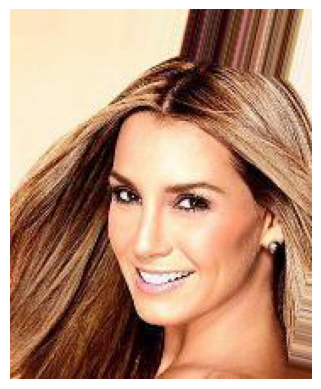

In [75]:
import os
from PIL import Image
import matplotlib.pyplot as plt

folder = "celeba_images/img_align_celeba"  # point to the subfolder
files = os.listdir(folder)

# Filter only image files (e.g., jpg, png)
image_files = [f for f in files if f.lower().endswith((".jpg", ".png"))]

# Pick the first image
img_path = os.path.join(folder, image_files[0])
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()


In [76]:
!pip install torchvision

In [77]:
import torch
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [78]:

# images load => transform => dataset of all imgs
class ImageProcessor:
    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        # list of paths for all images
        self.all_img_paths = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img

In [79]:
#try with colab->root_dir_path = "celeba_images/img_align_celeba"

transformations = transforms.Compose([
    transforms.CenterCrop(178), # 178x218 => 178x178
    transforms.Resize(64), # 64x64
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1]
])

In [80]:
dataset = ImageProcessor(root_dir_path, transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [81]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

In [82]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [83]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): # 3 is for RGB
        super(Generator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256
            nn.ReLU(),

            nn.Linear(256, 512), 
            nn.ReLU(),

            nn.Linear(512, 1024), 
            nn.ReLU(),

            nn.Linear(1024, 64 * 64 * img_channels), 
            nn.Tanh() # [-1, 1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64) 
        return img

        # fake img => 64 x 64 x 3 x batch_size

In [84]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3): # 3 is for RGB
        super(Discriminator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), # 4D tensor => 1D
            
            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1), 
            nn.Sigmoid() # probability of being real/fake 
        )

    def forward(self, img):
        return self.model(img)

In [85]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [86]:
import torch
# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device is {device}")

device is cpu


In [87]:
generator = generator.to(device)
discriminator = discriminator.to(device)

In [90]:
def train(generator, discriminator, dataloader, epochs=10):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1, 1, 1....]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0, 0, 0....]

            # Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size, 100).to(device))

            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the Generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}... G-loss:{g_loss}.... D-loss: {d_loss}")

        # save generated imgs for each epoch
        save_generated_images(generator, epoch, device) 

In [91]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

In [1]:
import os
print(os.path.abspath("DL-2.ipynb"))

C:\Users\sohai\AIML.ipynb\DL-2.ipynb
